In [1]:
#import relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
#Load the cleaned dataset
df= pd.read_csv(r"C:\MY DOCUMENTS\Saiket System Projects\Cleaned_Telco_Customer_Churn.csv")
print(df.head())
print(f"Dataset: {df.shape[0]} Customers | {df.shape[1]} Columns")

   customerid  gender seniorcitizen partner dependents  tenure phoneservice  \
0  7590-VHVEG  Female            No     Yes         No       1           No   
1  5575-GNVDE    Male            No      No         No      34          Yes   
2  3668-QPYBK    Male            No      No         No       2          Yes   
3  7795-CFOCW    Male            No      No         No      45           No   
4  9237-HQITU  Female            No      No         No       2          Yes   

      multiplelines internetservice onlinesecurity  ... streamingtv  \
0  No phone service             DSL             No  ...          No   
1                No             DSL            Yes  ...          No   
2                No             DSL            Yes  ...          No   
3  No phone service             DSL            Yes  ...          No   
4                No     Fiber optic             No  ...          No   

  streamingmovies        contract paperlessbilling              paymentmethod  \
0              No

In [5]:
#Summary statistics of numeric columns
print(df[['tenure','monthlycharges','totalcharges']].describe())

            tenure  monthlycharges  totalcharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


In [6]:
#Churn Analysis

churn_counts= df['churn'].value_counts()
churn_pct= df['churn'].value_counts(normalize= True)*100

print(f"Customers who churned : {churn_counts['Yes']} | Rate : {churn_pct['Yes']:.2f}%")
print(f"\nCustomers who did not churn : {churn_counts['No']} | Rate : {churn_pct['No']:.2f}%")

Customers who churned : 1869 | Rate : 26.54%

Customers who did not churn : 5174 | Rate : 73.46%


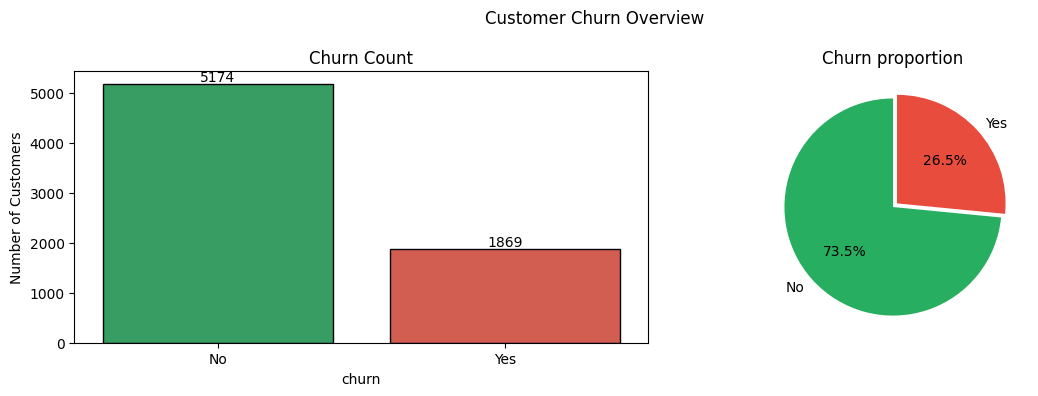

In [7]:
# Churn distribution(Bar chart and pie chart)
COLORS = {'No': '#27ae60', 'Yes': '#e74c3c'}
fig, axes = plt.subplots(1,2, figsize=(12, 4))
fig.suptitle('Customer Churn Overview')

sns.countplot(data=df,x='churn', hue='churn', palette= COLORS, edgecolor='black', ax= axes[0])
for container in axes[0].containers:
    axes[0].bar_label(container)
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')

axes[1].pie(churn_counts.values,
       labels=churn_counts.index,     
       colors=['#27ae60', '#e74c3c'],
       autopct='%1.1f%%',
       explode=(0, 0.05),
       startangle=90)
axes[1].set_title('Churn proportion')

plt.tight_layout()
plt.show()

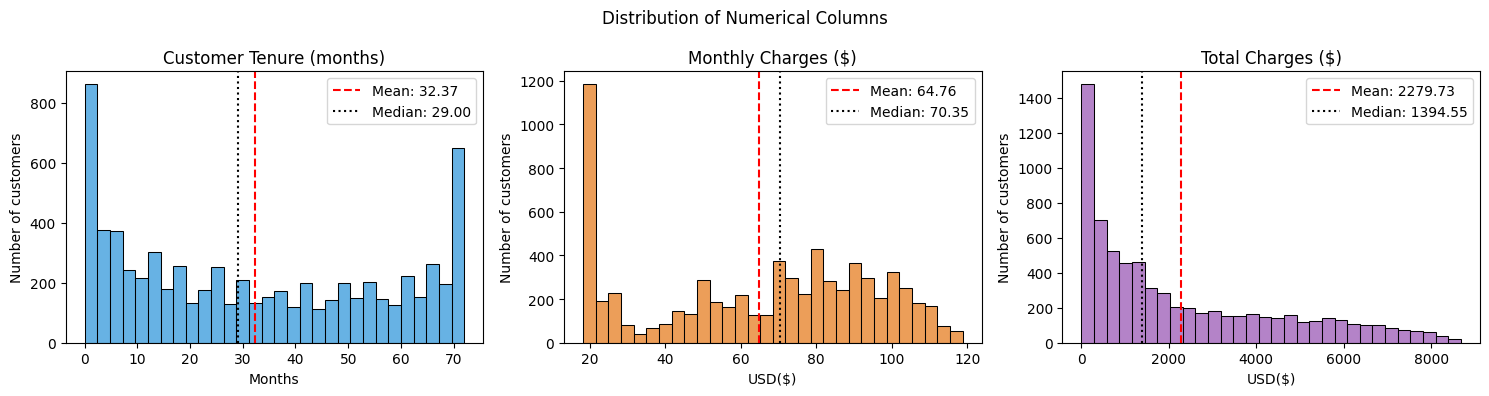

In [8]:
# Distribution of values in numerical columns
fig, axe= plt.subplots(1,3, figsize=(15, 4))
fig.suptitle('Distribution of Numerical Columns')

sns.histplot(df['tenure'], ax=axe[0], bins= 30, color= '#3498db')
axe[0].axvline(df['tenure'].mean(), color= 'red', linestyle= '--', label= f"Mean: {df['tenure'].mean():.2f}")
axe[0].axvline(df['tenure'].median(), color= 'black', linestyle= ':', label= f"Median: {df['tenure'].median():.2f}")
axe[0].set_title('Customer Tenure (months)')
axe[0].set_ylabel('Number of customers')
axe[0].set_xlabel('Months')
axe[0].legend()

sns.histplot(df['monthlycharges'], ax=axe[1], bins= 30, color= '#e67e22')
axe[1].axvline(df['monthlycharges'].mean(), color= 'red', linestyle= '--', label= f"Mean: {df['monthlycharges'].mean():.2f}")
axe[1].axvline(df['monthlycharges'].median(), color= 'black', linestyle= ':', label= f"Median: {df['monthlycharges'].median():.2f}")
axe[1].set_title('Monthly Charges ($)')
axe[1].set_ylabel('Number of customers')
axe[1].set_xlabel('USD($)')
axe[1].legend()


sns.histplot(df['totalcharges'], ax=axe[2], bins= 30, color='#9b59b6')
axe[2].axvline(df['totalcharges'].mean(), color= 'red', linestyle= '--', label= f"Mean: {df['totalcharges'].mean():.2f}")
axe[2].axvline(df['totalcharges'].median(), color= 'black', linestyle= ':', label= f"Median: {df['totalcharges'].median():.2f}")
axe[2].set_title('Total Charges ($)')
axe[2].set_ylabel('Number of customers')
axe[2].set_xlabel('USD($)')
axe[2].legend()

plt.tight_layout()
plt.show()

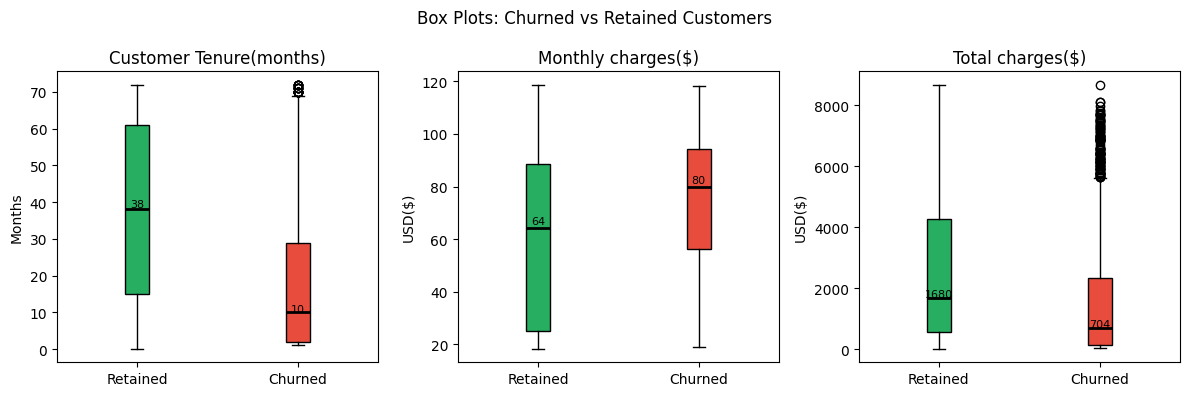

In [9]:
# Churned vs Retained customers on boxplot
fig, axes= plt.subplots(1, 3, figsize= (12, 4))
fig.suptitle('Box Plots: Churned vs Retained Customers')

cols= ['tenure', 'monthlycharges', 'totalcharges']
titles= ['Customer Tenure(months)', 'Monthly charges($)','Total charges($)']
ylabels= ['Months','USD($)','USD($)']
for ax, col, title, ylabel in zip(axes, cols, titles, ylabels):
    churned= df[df['churn']== 'Yes'][col]
    retained= df[df['churn']== 'No'][col]

    ax.boxplot([retained, churned],
            tick_labels=['Retained', 'Churned'],
            patch_artist= True,
            medianprops= dict(color= 'black', linewidth= 2))
    
    # Color the two boxes green and red
    ax.patches[0].set_facecolor('#27ae60')  
    ax.patches[1].set_facecolor('#e74c3c') 
    ax.set_title(title)
    ax.set_ylabel(ylabel)

    for i, data in enumerate([retained, churned]):
        ax.text(i + 1, data.median() * 1.02,
                f'{data.median():.0f}',
                ha='center', fontsize= 8)


plt.tight_layout()
plt.show()

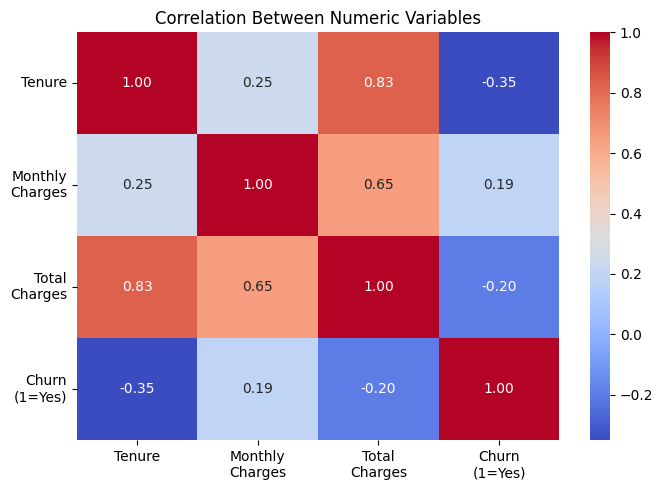

In [10]:
# Correlation Between Numeric Variables in a heatmap
fig, ax = plt.subplots(figsize= (7, 5))

numeric_df= df[['tenure', 'monthlycharges', 'totalcharges', 'numeric_churn']]
corr= numeric_df.corr().round(2)
sns.heatmap(corr, 
            annot= True,
            fmt= '.2f',
            cmap= 'coolwarm',
            ax= ax
            )

ax.set_title('Correlation Between Numeric Variables')
ax.set_xticklabels(['Tenure', 'Monthly\nCharges', 'Total\nCharges', 'Churn\n(1=Yes)'])
ax.set_yticklabels(['Tenure', 'Monthly\nCharges', 'Total\nCharges', 'Churn\n(1=Yes)'])

plt.tight_layout()
plt.show() 

In [11]:
# correlation insights
print(f"  tenure vs numeric_churn       : {corr.loc['tenure','numeric_churn']:.2f}  → Longer tenure = LESS likely to churn")
print(f"  monthlycharges vs numeric_churn: {corr.loc['monthlycharges','numeric_churn']:.2f}  → Higher charges = MORE likely to churn")
print(f"  tenure vs totalcharges        : {corr.loc['tenure','totalcharges']:.2f}  → Longer customers pay more total (expected)")

  tenure vs numeric_churn       : -0.35  → Longer tenure = LESS likely to churn
  monthlycharges vs numeric_churn: 0.19  → Higher charges = MORE likely to churn
  tenure vs totalcharges        : 0.83  → Longer customers pay more total (expected)
